# Is Australia Doing Well?
### Beyond the single number: a well-being audit of Australia, 2010–2024
**Winter Data Analysis Challenge 2026 · Reproducible report**

---

> **The one-line answer.** It depends entirely on what you measure — and that is not a cop-out, it is the finding. By the ledger of the 20th century (income, jobs, life expectancy) Australia is doing well. By the ledger of the 21st (loneliness, distress, heat, housing) it is quietly slipping. Any single "score" hides this, so this report is built to *resist* being collapsed into one.

**Data:** OECD *How's Life?* Well-being Database (national averages, 2010–2024), 21 indicators across 11 well-being domains for 47 countries.
**Method in one breath:** clean → orient every indicator so "higher = better" → standardise each against the OECD → look at Australia three ways: *where it ranks now*, *which way it is moving*, and *what we cannot even measure*.

## 1. Refining a deliberately vague question

"Is Australia doing well?" has no answer until we decide three things: **well at what**, **compared to whom**, and **over what horizon**. Rather than pick one and pretend it is *the* answer, this report treats the vagueness as the subject. We break the question into three answerable sub-questions and let them disagree:

1. **Snapshot — where does Australia stand today** relative to the OECD, indicator by indicator?
2. **Trajectory — is Australia improving or declining** across 2010–2024?
3. **Blind spots — what can we not even measure**, and does that absence bias the story?

We deliberately build a single composite "well-being score" — and then spend as much effort showing *why you should not trust it* as computing it. That tension is the analytical core of the report.

## 2. The data

The OECD *How's Life?* database operationalises well-being as **11 dimensions** spanning material conditions (income, housing, jobs), quality of life (health, knowledge, environment, safety, subjective well-being) and community (work–life balance, social connections, civic engagement). Our extract carries **21 headline indicators**, each a national average, for **47 countries** over **2010–2024** (a few series extend to 2025–26 as provisional/estimated).

A subtle trap sits in the raw file: the OECD's SDMX export ships every field **twice** — a machine code (`OBS_VALUE`, `TIME_PERIOD`) and a human-readable twin (`Observation value`, `Time period`). In this extract **the human-readable value column is entirely empty**; a naïve `read_csv` + "use the nice column names" would silently produce a dataset of all-nulls. We handle this explicitly below.

In [4]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl, pathlib, warnings
warnings.filterwarnings("ignore")

# --- Reproducible path resolution: find the CSV wherever the notebook is run ---
CANDIDATES = [
    "OECD Data.csv",
    "winter data analysis challenge/OECD Data.csv",
    "/sessions/practical-modest-lovelace/mnt/winter data analysis challenge/OECD Data.csv",
]
SRC = next((p for p in CANDIDATES if pathlib.Path(p).exists()), None)
assert SRC, "Place 'OECD Data.csv' next to this notebook."
raw = pd.read_csv(SRC)
print("Raw shape:", raw.shape)
print("Human-readable 'Observation value' non-null:", raw['Observation value'].notna().sum(),
      "  <-- the trap: it is empty")
print("Machine 'OBS_VALUE' non-null:", raw['OBS_VALUE'].notna().sum())

Raw shape: (8806, 30)
Human-readable 'Observation value' non-null: 0   <-- the trap: it is empty
Machine 'OBS_VALUE' non-null: 8806


### 2.1 Cleaning

Five concrete decisions, each defensible and each logged:

1. **Keep the columns that carry data.** Use `OBS_VALUE` / `TIME_PERIOD`, discard the empty human-readable twins, coerce to numeric/int.
2. **Assign directionality.** Half of these indicators are "bad" (deaths of despair, air pollution, long hours). A well-being score cannot average raw values that point in opposite directions. We attach a `direction` (+1 higher-is-better, −1 lower-is-better) to every indicator, sourced from the OECD metadata definitions.
3. **Separate OECD members from accession/partner economies.** "Compared to the OECD" should mean the OECD; nine partner economies (Brazil, Indonesia, South Africa, …) are flagged and excluded from the benchmark average, though retained for context.
4. **Preserve quality flags.** ~3% of observations are estimated, provisional, definition-break or time-series-break. We keep `OBS_STATUS` rather than dropping, so caveats travel with the data.
5. **Respect sparsity.** Four indicators (time off, social interactions, overcrowding, gender gap in working hours) are essentially never observed for Australia — a finding in itself (see §6), not a row to quietly impute.

In [6]:
df = raw[['Reference area','MEASURE','Measure','Domain','Unit of measure',
          'TIME_PERIOD','OBS_VALUE','Observation status']].copy()
df = df.rename(columns={'Reference area':'country','MEASURE':'ind','Measure':'indicator',
                        'Domain':'domain','Unit of measure':'unit','TIME_PERIOD':'year',
                        'OBS_VALUE':'value','Observation status':'status'})
df['year']  = df['year'].astype(int)
df['value'] = pd.to_numeric(df['value'], errors='coerce')

# (2) Directionality: +1 higher-is-better, -1 lower-is-better  (from OECD metadata)
DIRECTION = {'1_1':+1,'1_2':-1,'1_3':+1,'2_1':+1,'2_2':-1,'2_7':-1,'3_1':-1,'3_2':-1,
             '4_1':+1,'4_3':-1,'5_1':+1,'5_3':-1,'6_2':+1,'7_1_DEP':-1,'7_2':+1,
             '8_1_DEP':-1,'8_2':+1,'9_2':-1,'9_3':-1,'11_1':+1,'11_2':-1}
df['direction'] = df['ind'].map(DIRECTION)
assert df['direction'].notna().all()

# (3) OECD membership flag
NON_OECD = {'Argentina','Brazil','Bulgaria','Indonesia','Peru','Romania',
            'South Africa','Thailand','Croatia'}
df['oecd'] = ~df['country'].isin(NON_OECD)

print(f"Clean tidy frame: {df.shape[0]} rows, {df['country'].nunique()} countries, "
      f"{df['ind'].nunique()} indicators, {df['domain'].nunique()} domains, "
      f"years {df['year'].min()}-{df['year'].max()}")
print("\nData-quality flags retained:")
print(df['status'].value_counts().to_string())

Clean tidy frame: 8806 rows, 47 countries, 21 indicators, 10 domains, years 2010-2026

Data-quality flags retained:
status
Normal value          8540
Estimated value         92
Provisional value       89
Definition differs      45
Time series break       40


### 2.2 Method, stated honestly

To compare a suicide rate (deaths per 100 000) with life satisfaction (0–10) we put every indicator on one scale. For each indicator we compute a **z-score across OECD countries** using each country's **latest value in 2021–2024** (robust to the ragged reporting calendar), then multiply by `direction` so that **positive always means better**. A country's **composite** is the mean of its **domain** z-scores (equal weight per domain, so a data-rich domain like Work & Job Quality does not dominate a thin one like Civic Engagement).

Three honest caveats we will act on, not bury:

- **Equal weighting is a value judgement**, not a fact. §5 tests how much it matters.
- **Z-scoring measures Australia relative to its peers**, so "improvement" of the pack can look like Australian decline and vice-versa. §6 uses raw within-country change to cross-check.
- **National averages are ecological**: they say nothing about *who* inside Australia is doing well. We flag where this bites hardest.

In [8]:
def latest_in_window(g, lo=2021, hi=2024):
    g = g[(g.year>=lo)&(g.year<=hi)].sort_values('year')
    return g['value'].iloc[-1] if len(g) else np.nan

oecd = df[df.oecd]
cs = (oecd.groupby(['ind','indicator','domain','direction','country'])
          .apply(latest_in_window).rename('value').reset_index().dropna(subset=['value']))

def zscore(g):
    m, s = g['value'].mean(), g['value'].std(ddof=0)
    g['z'] = (g['value']-m)/s * g['direction'].iloc[0]
    g['rank'] = g['value'].rank(ascending=(g['direction'].iloc[0] < 0))  # 1 = best
    g['n'] = len(g)
    return g
cs = cs.groupby('ind', group_keys=False).apply(zscore)
print("Standardised cross-section ready:", cs.shape[0], "country-indicator cells")

Standardised cross-section ready: 604 country-indicator cells


## 3. Finding 1 — Australia is not one thing

The first figure is the whole argument in miniature. Standardised against the OECD, Australia is **best in the club at voter turnout**, top-ten on income and life expectancy — and simultaneously **bottom-quartile on long working hours, negative emotions and exposure to extreme heat**. There is no single "Australia": there is a country that is excellent, average and poor *at the same time*, depending on the row you read.

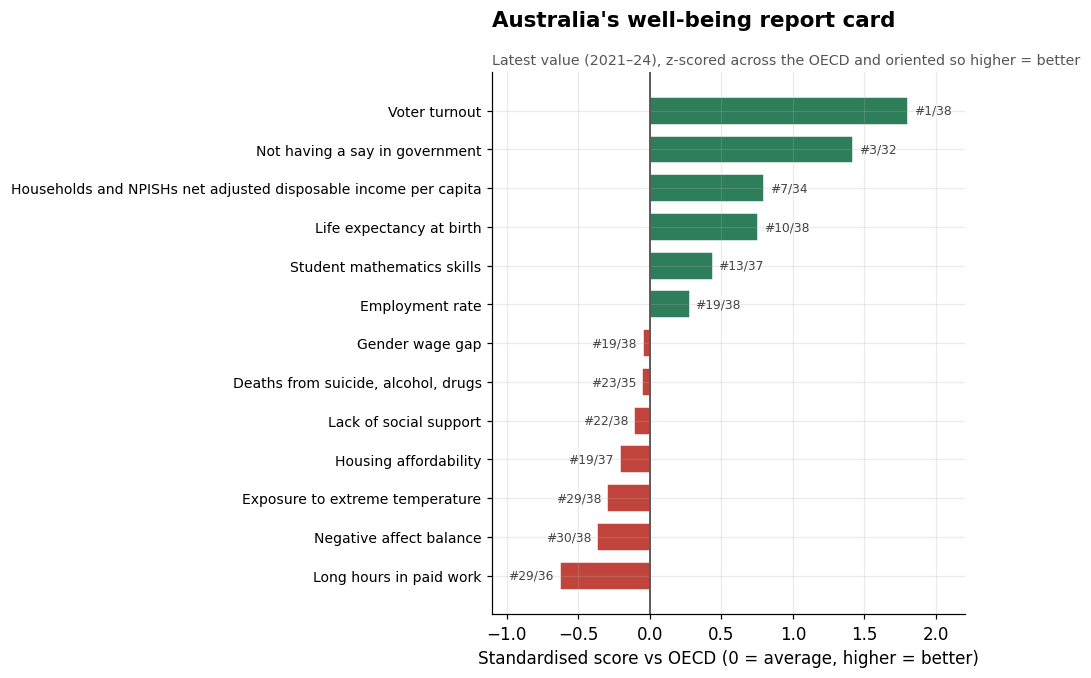

In [10]:
NAVY,RED,GREEN,GREY,GOLD = '#1b3a5b','#c1443c','#2e7d5b','#9aa5b1','#e0a92e'
mpl.rcParams.update({'font.size':11,'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':.25,'figure.dpi':110})

a = cs[cs.country=='Australia'].sort_values('z')
fig, ax = plt.subplots(figsize=(9,6.3))
ax.barh(range(len(a)), a.z, color=[GREEN if z>0 else RED for z in a.z], edgecolor='white', height=.72)
ax.set_yticks(range(len(a))); ax.set_yticklabels(a.indicator, fontsize=9.2)
ax.axvline(0, color='#333', lw=1)
for y,(z,r,n) in enumerate(zip(a.z,a['rank'],a.n)):
    ax.text(z+(.04 if z>0 else -.04), y, f"#{int(r)}/{int(n)}", va='center',
            ha='left' if z>0 else 'right', fontsize=8, color='#444')
ax.set_xlim(-1.1, 2.2); ax.set_xlabel("Standardised score vs OECD (0 = average, higher = better)")
ax.set_title("Australia's well-being report card", fontweight='bold', fontsize=14, loc='left', pad=30)
ax.text(0,1.008,"Latest value (2021–24), z-scored across the OECD and oriented so higher = better",
        transform=ax.transAxes, fontsize=9.3, color='#555', va='bottom')
plt.tight_layout(); plt.show()

## 4. Finding 2 — one number, many answers

Collapse the report card into a single composite and Australia lands **14th of 38 OECD countries** — respectably upper-middle, behind every Nordic and, tellingly, behind **New Zealand (4th)**. But a rank is only as trustworthy as its recipe. Two stress-tests:

- **Does the normalisation method matter?** Swapping z-scores for min–max rescaling leaves Australia at 14th; switching to indicator-equal weights moves it to 13th. The rank is **robust to *how* we standardise**.
- **Does the *composition* matter?** This is where it breaks. Remove any one domain and re-rank: Australia swings between **13th and 22nd**. Drop **Civic Engagement alone and Australia falls eight places to 22nd** — because its flagship strength, near-universal voter turnout, is largely an artefact of **compulsory voting**, an institutional rule, not a spontaneous signal of a flourishing society.

The composite is not *wrong*; it is *contingent*. The honest headline is a range, not a number.

In [12]:
def composite(frame):
    dom = frame.groupby(['country','domain'])['z'].mean().reset_index()
    return dom.groupby('country')['z'].mean()

base = composite(cs).sort_values(ascending=False)
rank_of = lambda s,c='Australia': int(s.rank(ascending=False)[c])
print(f"Australia composite rank (equal domain weights): {rank_of(base)} / {base.size}")

# Sensitivity A: normalisation method
def minmax(frame):
    c = frame.copy()
    def mm(g):
        lo,hi=g.value.min(),g.value.max(); s=(g.value-lo)/(hi-lo)
        g['z']=np.where(g.direction.iloc[0]>0,s,1-s); return g
    return composite(c.groupby('ind',group_keys=False).apply(mm))
ind_equal = cs.groupby('country')['z'].mean()
print(f"  ... under min–max normalisation:  {rank_of(minmax(cs).sort_values(ascending=False))}")
print(f"  ... under indicator-equal weights:{rank_of(ind_equal.sort_values(ascending=False)):>3}")

# Sensitivity B: leave-one-domain-out
print("\nLeave-one-domain-out — Australia's rank swings:")
loo = {}
for d in sorted(cs.domain.unique()):
    r = rank_of(composite(cs[cs.domain!=d]).sort_values(ascending=False))
    loo[d] = r
    print(f"  drop {d:24s}: {r}")
print(f"\n==> Australia is anywhere from {min(loo.values())}th to {max(loo.values())}th "
      f"depending on which domain you drop. Civic Engagement is the load-bearing wall.")

Australia composite rank (equal domain weights): 14 / 38
  ... under min–max normalisation:  14
  ... under indicator-equal weights: 13

Leave-one-domain-out — Australia's rank swings:
  drop Civic engagement        : 22
  drop Environmental quality   : 13
  drop Health                  : 16
  drop Housing                 : 14
  drop Income and wealth       : 16
  drop Knowledge and skills    : 15
  drop Social connections      : 13
  drop Subjective well-being   : 13
  drop Work and job quality    : 14
  drop Work-life balance       : 15

==> Australia is anywhere from 13th to 22th depending on which domain you drop. Civic Engagement is the load-bearing wall.


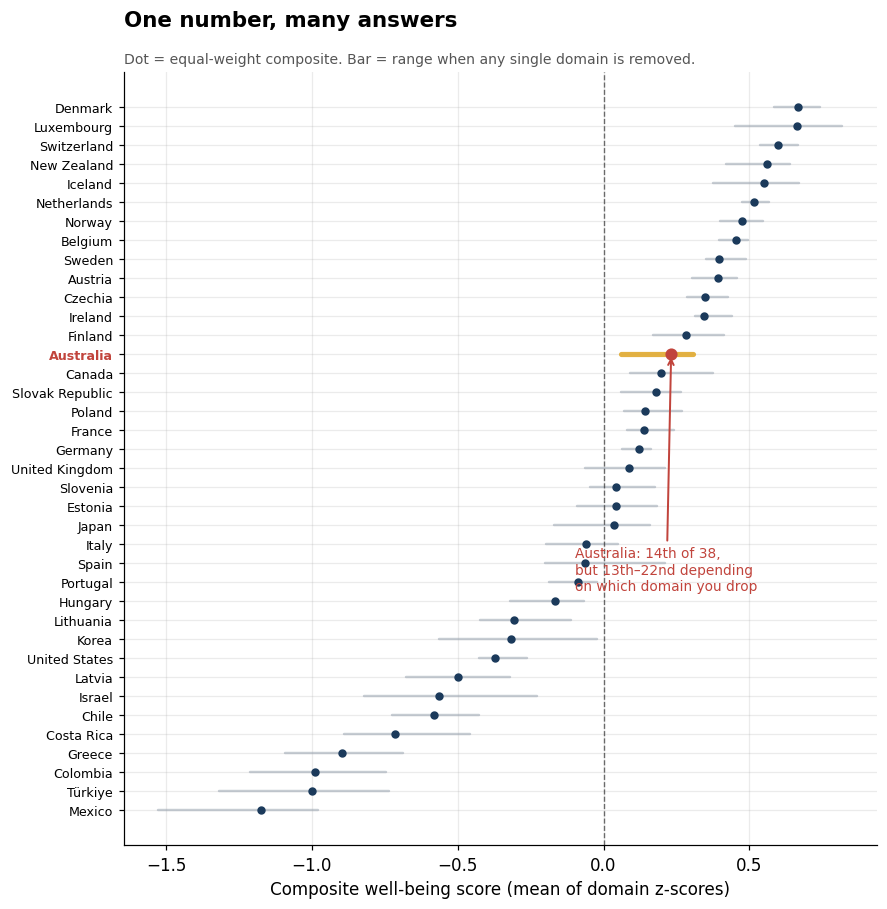

In [13]:
# Figure 2: ranking with a leave-one-domain-out sensitivity band
loo_scores = pd.DataFrame({d: composite(cs[cs.domain!=d]) for d in cs.domain.unique()})
band = pd.DataFrame({'lo':loo_scores.min(1),'hi':loo_scores.max(1),'base':base}).sort_values('base')

fig, ax = plt.subplots(figsize=(8.2,8.4))
for i,(c,row) in enumerate(band.iterrows()):
    hl = c=='Australia'
    ax.plot([row.lo,row.hi],[i,i], color=GOLD if hl else GREY, lw=3.4 if hl else 1.6,
            solid_capstyle='round', alpha=.9 if hl else .55, zorder=2)
    ax.scatter(row.base, i, color=RED if hl else NAVY, s=48 if hl else 20, zorder=3)
ax.set_yticks(range(len(band))); ax.set_yticklabels(band.index, fontsize=8.3)
for t in ax.get_yticklabels():
    if t.get_text()=='Australia': t.set_color(RED); t.set_fontweight('bold')
ax.axvline(0, color='#333', lw=.9, ls='--', alpha=.7)
ax.set_xlabel("Composite well-being score (mean of domain z-scores)")
ax.set_title("One number, many answers", fontweight='bold', fontsize=14, loc='left', pad=30)
ax.text(0,1.008,"Dot = equal-weight composite. Bar = range when any single domain is removed.",
        transform=ax.transAxes, fontsize=9.2, color='#555', va='bottom')
ax.annotate("Australia: 14th of 38,\nbut 13th–22nd depending\non which domain you drop",
    xy=(band.loc['Australia','base'], list(band.index).index('Australia')),
    xytext=(0.60,0.33), textcoords='axes fraction', fontsize=9, color=RED,
    arrowprops=dict(arrowstyle='->', color=RED, lw=1.3))
plt.tight_layout(); plt.show()

## 5. Finding 3 — a two-speed nation

Ranking is a snapshot; the more revealing question is *which way is Australia moving*. For every indicator with a usable series we take the raw change from 2010 to its latest reading and orient it so **positive = improvement**. The pattern is stark and coherent:

**The material ledger is improving.** Real household income is up ~14%, employment up ~5 points (6%), the gender wage gap and long working hours have both fallen by roughly a quarter, life expectancy edged up.

**The human ledger is deteriorating — fast.** Reported *lack of social support* has **doubled**, *deaths from suicide, alcohol and drugs* are up **~49%**, *negative affect* up ~21%, and *exposure to extreme temperature* up ~13%. Roughly half the indicators improved and half worsened — a near-perfect split that, once again, refuses a one-word verdict. Australia is getting **richer and safer at work, but lonelier, more distressed and hotter.**

Of 15 Australian series with a trend: 8 improved, 7 worsened.


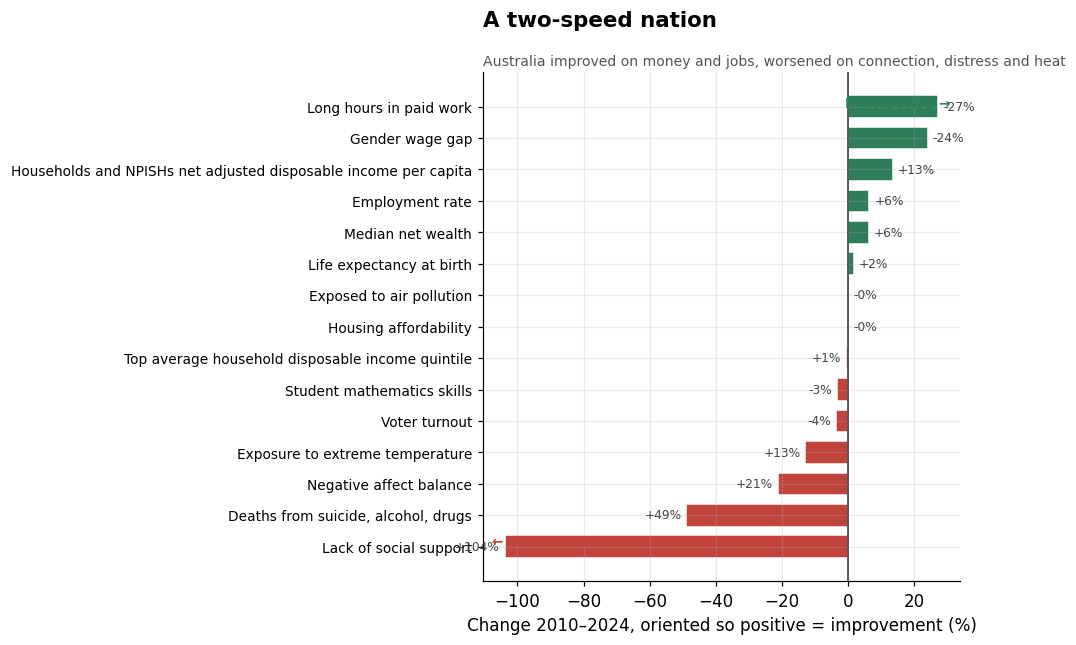

In [15]:
traj = []
for ind, g in df[df.country=='Australia'].groupby('ind'):
    g = g[(g.year>=2010)&(g.year<=2024)].dropna(subset=['value']).sort_values('year')
    if len(g) < 4: continue
    first, last = g.value.iloc[0], g.value.iloc[-1]
    pct = (last-first)/abs(first)*100 if first else np.nan
    traj.append({'indicator':g.indicator.iloc[0], 'direction':g.direction.iloc[0],
                 'pct':pct, 'adj':pct*g.direction.iloc[0]})   # adj>0 => improvement
tr = pd.DataFrame(traj).sort_values('adj')
imp = (tr.adj>0).sum()
print(f"Of {len(tr)} Australian series with a trend: {imp} improved, {len(tr)-imp} worsened.")

fig, ax = plt.subplots(figsize=(9,6))
ax.barh(range(len(tr)), tr.adj, color=[GREEN if v>0 else RED for v in tr.adj], edgecolor='white', height=.72)
ax.set_yticks(range(len(tr))); ax.set_yticklabels(tr.indicator, fontsize=9)
ax.axvline(0, color='#333', lw=1)
for y,(v,raw) in enumerate(zip(tr.adj,tr.pct)):
    ax.text(v+(1.5 if v>0 else -1.5), y, f"{raw:+.0f}%", va='center',
            ha='left' if v>0 else 'right', fontsize=8, color='#444')
ax.set_xlabel("Change 2010–2024, oriented so positive = improvement (%)")
ax.set_title("A two-speed nation", fontweight='bold', fontsize=14, loc='left', pad=30)
ax.text(0,1.008,"Australia improved on money and jobs, worsened on connection, distress and heat",
        transform=ax.transAxes, fontsize=9.2, color='#555', va='bottom')
ax.text(.98,.93,"IMPROVING →", transform=ax.transAxes, ha='right', color=GREEN, fontweight='bold', fontsize=9)
ax.text(.02,.07,"← WORSENING", transform=ax.transAxes, ha='left', color=RED, fontweight='bold', fontsize=9)
plt.tight_layout(); plt.show()

## 6. Finding 4 — the questions we cannot answer

A well-being audit should be honest about its own holes. Of the 21 indicators, **four are never observed for Australia** in this extract (time off, time in social interactions, household overcrowding, the gender gap in working hours) and **four more go dark after 2020** — including, pointedly, **life satisfaction**, the single indicator that speaks most directly to the challenge's own example question, *"Do Australians feel happy?"*

This is not a footnote; it is a structural bias. The series that survive are disproportionately the **easy-to-count material ones** (income, employment, life expectancy). The **subjective and relational** dimensions — exactly where §5 shows Australia deteriorating — are the ones the data lets go quiet. Any composite therefore flatters Australia by construction: it scores loudest on the country's strengths and stays silent on its emerging weaknesses.

Australia: data ever for 17/21 indicators; only 13/21 have any reading after 2020.


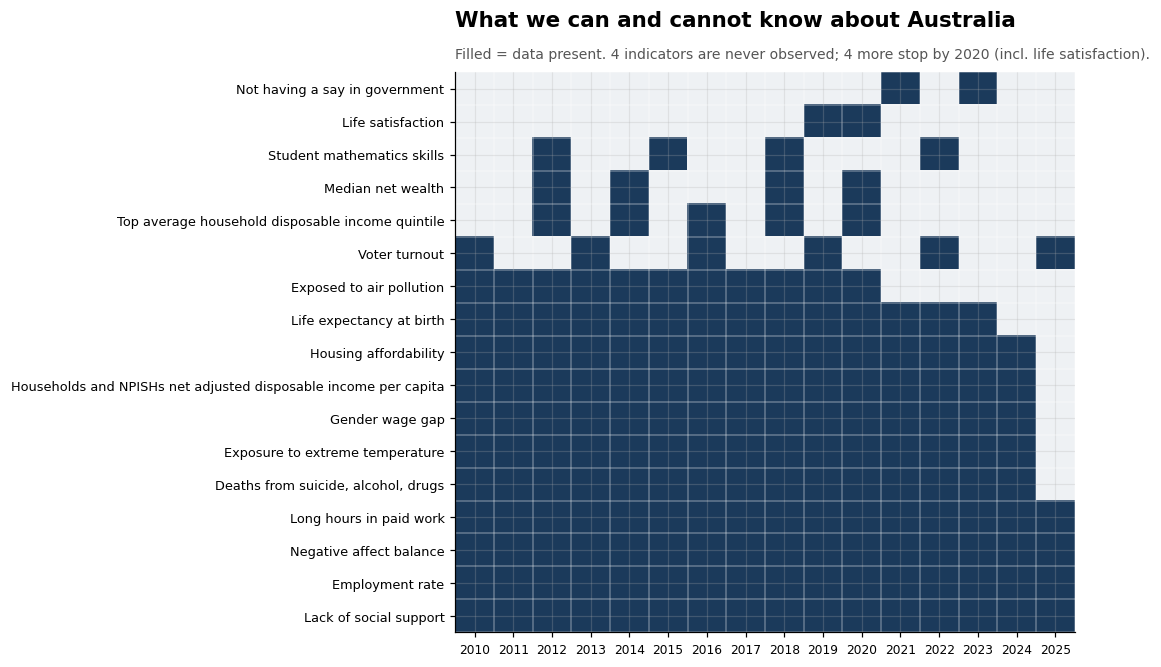

In [17]:
aus = df[df.country=='Australia']
piv = aus.pivot_table(index='indicator', columns='year', values='value', aggfunc='first')
piv = piv.reindex(sorted(piv.columns), axis=1)
present = piv.loc[piv.notna().sum(1).sort_values().index].notna().astype(int)

n_ever = aus.ind.nunique(); n_recent = aus[aus.year>2020].ind.nunique()
print(f"Australia: data ever for {n_ever}/21 indicators; only {n_recent}/21 have any reading after 2020.")

fig, ax = plt.subplots(figsize=(10,6.2))
ax.imshow(present, aspect='auto', vmin=0, vmax=1,
          cmap=mpl.colors.ListedColormap(['#eef1f4', NAVY]))
ax.set_xticks(range(len(present.columns))); ax.set_xticklabels(present.columns, fontsize=8)
ax.set_yticks(range(len(present.index)));   ax.set_yticklabels(present.index, fontsize=8.4)
ax.set_xticks(np.arange(-.5,len(present.columns),1), minor=True)
ax.set_yticks(np.arange(-.5,len(present.index),1), minor=True)
ax.grid(which='minor', color='white', lw=1.3); ax.tick_params(which='minor', length=0)
ax.set_title("What we can and cannot know about Australia", fontweight='bold', fontsize=14, loc='left', pad=30)
ax.text(0,1.02,"Filled = data present. 4 indicators are never observed; 4 more stop by 2020 (incl. life satisfaction).",
        transform=ax.transAxes, fontsize=9.2, color='#555', va='bottom')
plt.tight_layout(); plt.show()

## 7. Critical assessment — why every number above deserves a raised eyebrow

- **Ecological fallacy.** Every figure is a national average. Australia's headline income can rise while renters and young people go backwards; the average is silent on distribution. Where the OECD offers inequality cuts (S80/S20, gender wage gap) the picture is less rosy than the mean.
- **Relative, not absolute.** Z-scores measure Australia *against the pack*. If the whole OECD improves, standing still reads as decline. §5's raw within-country trends are the antidote and were included for exactly this reason.
- **The compulsory-voting artefact.** Australia's single biggest "win" is institutionally mandated. Treating it as evidence of civic flourishing — and letting it lift the composite eight places — would be a category error. This is the clearest case of a metric measuring a *rule*, not a *reality*.
- **Endpoint sensitivity.** Trend percentages depend on the 2010 baseline and the (sometimes provisional) latest point; the *direction* of the material-vs-human split is robust, the exact magnitudes are not.
- **Survivorship in the data itself.** As §6 shows, the indicators that persist are the ones that flatter Australia. The deterioration is likely *understated* because its natural home — subjective and relational data — is the first to disappear.
- **Equal weighting is an assumption.** A government that prizes GDP would weight differently and reach "Australia is thriving"; one that prizes belonging would reach the opposite. We showed the range rather than smuggle in a preference.

## 8. The wider context

In **July 2023 the Australian Treasury released *Measuring What Matters*, the country's first national well-being framework** — five themes, twelve dimensions, fifty indicators — explicitly to track progress *"beyond economic measures"* (responsibility for the dashboard passed to the ABS in 2024). Australia has, in other words, **officially conceded the premise of this report**: that GDP and the single number are inadequate, and that health, security, sustainability and social cohesion must be read together.

Our findings map cleanly onto that framework and onto Australia's lived debate. The material strengths echo the enduring **"lucky country"** story — resource wealth, a resilient labour market, long lives. The deterioration we isolate — **doubling loneliness, rising deaths of despair, worsening heat exposure, chronically stretched housing affordability** — is precisely the terrain of Australia's cost-of-living, mental-health and climate-adaptation politics of the mid-2020s. The data do not just answer "is Australia doing well?"; they locate *where the national conversation should be pointed*: not at the income line, which is fine, but at connection, distress and the physical climate.

## 9. Conclusion

**Is Australia doing well? Yes, and no — and the "and no" is the part worth acting on.**

Measured by the instruments the 20th century trusted — income, employment, longevity — Australia is a clear success and, on the trend, still improving. Measured by the instruments the 21st century is learning to trust — social connection, mental distress, exposure to a warming climate — Australia is going backwards, and the data infrastructure is quietly losing sight of exactly those dimensions. A single composite ranks it a comfortable 14th of 38 and, in doing so, **hides its most important story.**

The right answer to a vague question is not a confident number. It is a **decomposition that tells you where to look** — and everything above is built to point Australia at the ledger it is failing, not the one it has already won.

---
*Reproducibility: place `OECD Data.csv` beside this notebook and Run All. Requires only `pandas`, `numpy`, `matplotlib`. Source: OECD How's Life? Well-being Database (extract 2010–2024).*